# plot_dmrg_quality / plot_dmrg_quantity

Notebook do rysowania przebiegu jakości i wielkości z pliku `dmrg_log.dat`.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def yperiodic_string(x):
    return "true" if as_bool(x) else "false"


def results_geometry_folder(plot_type):
    """
    Zamienia nazwę geometrii używaną w funkcjach rysujących
    na nazwę katalogu w results/.

    Przykłady:
        plot_type="pila"      -> results/saw/
        plot_type="truesnake" -> results/truesnake/
    """
    key = str(plot_type).lower()

    if key in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "saw"

    if key in ["truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    if key in ["snake", "semisnake", "semi-snake"]:
        return "snake"

    if key in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne ścieżki: "
        "'saw'/'pila', 'truesnake', 'snake', 'snake_rows'."
    )

def load_dmrg_log(plot_type="truesnake", mg_site_val=None):
    geometry = results_geometry_folder(plot_type)
    mg_site_used = mg_site if mg_site_val is None else mg_site_val
    yp = yperiodic_string(yperiodic)

    folder = (
        f"{Nx}x{Ny}_PBC={yp}_"
        f"Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
    )

    subfolder = f"Savrg_theta={theta}_phi={phi}_{mg_site_used}"

    file_path = (
        "results/" +
        geometry + "/" +
        folder + "/" +
        subfolder + "/" +
        "dmrg_log.dat"
    )

    data = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        names=["sweep", "energy", "spin", "maxdim", "dmrg_maxerr"]
    )

    return data, file_path


def plot_dmrg_quantity(
    plot_quantity="energy",
    plot_type="truesnake",
    logy=False,
    marker="o",
    mg_site_val=None,
    angles=None,
):
    """
    Rysuje wybraną wielkość z dmrg_log.dat.

    plot_type może być:
        - pojedynczym stringiem, np. "truesnake" lub "pila"
        - listą, np. ["pila", "truesnake"], wtedy krzywe są porównywane na jednym wykresie

    Parametr angles jest zostawiony jako opcjonalny dla zgodności
    ze starszym wywołaniem, ale obecnie nie zmienia ścieżki.
    """
    allowed = ["energy", "spin", "maxdim", "dmrg_maxerr"]

    if plot_quantity not in allowed:
        raise ValueError(f"plot_quantity must be one of: {allowed}")

    plot_types = [plot_type] if isinstance(plot_type, str) else list(plot_type)

    if len(plot_types) == 0:
        raise ValueError("plot_type nie może być pustą listą.")

    plt.figure(figsize=(7, 4.5))

    loaded = {}

    for pt in plot_types:
        data, file_path = load_dmrg_log(
            plot_type=pt,
            mg_site_val=mg_site_val,
        )

        print("Reading from:")
        print(file_path)

        label = results_geometry_folder(pt)
        plt.plot(
            data["sweep"],
            data[plot_quantity],
            marker=marker,
            label=label if len(plot_types) > 1 else None,
        )

        loaded[pt] = data

    plt.xlabel("Sweep")
    plt.ylabel(plot_quantity)
    plt.title(f"{plot_quantity}(sweep)")

    if logy:
        plt.yscale("log")

    if len(plot_types) > 1:
        plt.legend()

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if len(plot_types) == 1:
        return loaded[plot_types[0]]

    return loaded



# Alias zgodny z nazwą pliku / potoczną nazwą funkcji
def plot_dmrg_quality(*args, **kwargs):
    return plot_dmrg_quantity(*args, **kwargs)

In [2]:
"""
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"
    """

Nx = 5
Ny = 4

secondspin = False
fixed_pos = 2

component = "Sx"
mg_site = 20

yperiodic = "false"

Jx = -1.0
Jy = -1.0
Jz = -1.0
r = 1.0

theta = 0.0
phi = 0.0

Reading from:
results/truesnake/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=1.0/Savrg_theta=0.0_phi=0.0_20/dmrg_log.dat


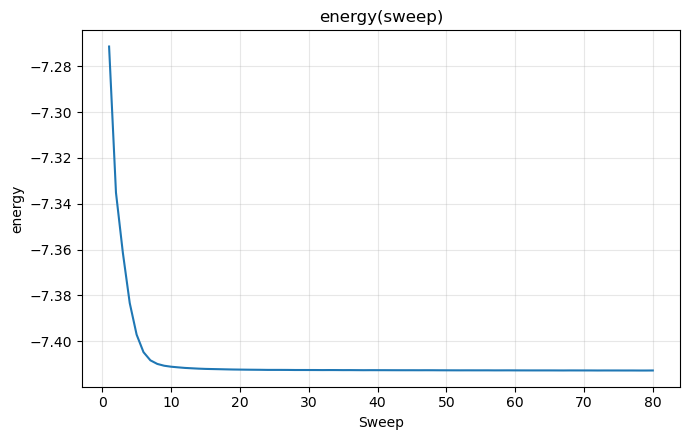

,sweep,energy,spin,maxdim,dmrg_maxerr
0,1,-7.271436,0.514043,50,2.475528e-04
1,2,-7.335168,0.499207,100,7.433513e-05
2,3,-7.361380,0.495315,150,6.119098e-05
3,4,-7.383337,0.494123,200,6.036002e-05
4,5,-7.397114,0.493002,300,1.951974e-05
...,...,...,...,...,...
75,76,-7.412763,0.460386,1760,1.080027e-07
76,77,-7.412759,0.460378,1753,8.839967e-08
77,78,-7.412776,0.460372,1842,7.958307e-08
78,79,-7.412775,0.460365,1821,4.006542e-08


In [11]:
# Dostępne: "energy", "spin", "maxdim", "dmrg_maxerr"
plot_dmrg_quality(
    plot_quantity="energy",
    plot_type="truesnake",
    logy=False,
    marker=None,
    angles="all",
)